## Load packages

In [1]:
# import packages
import rioxarray as rxr
import xarray as xr
import numpy as np
import geopandas as gpd
from scipy.ndimage import generic_filter
import matplotlib.pyplot as plt
from rasterio.plot import show
from rasterio.features import rasterize
from rasterio.enums import Resampling
from pykrige.ok import OrdinaryKriging
from scipy.spatial import cKDTree
from scipy.ndimage import distance_transform_edt

# set random seed
np.random.seed(42)

## Fix Scanlines

In [2]:
# set soc filepaths
soc_path = './carbon_stock_data/final_layers_clipped/soc_0_1m_kg_m2_sothe.tif'
soc_scanline_poly_path = './carbon_stock_data/soc_correction/scanline_polygon.shp'

In [3]:
# Load soc raster
soc = rxr.open_rasterio(soc_path).squeeze()  # drop band dim

# Mask nodata
nodata = soc.rio.nodata
if nodata is not None:
    soc = soc.where(soc != nodata)

# Get CRS
src_crs = soc.rio.crs

# Load scanline polygon
scanline_poly = gpd.read_file(soc_scanline_poly_path)
scanline_poly = scanline_poly.to_crs(src_crs)

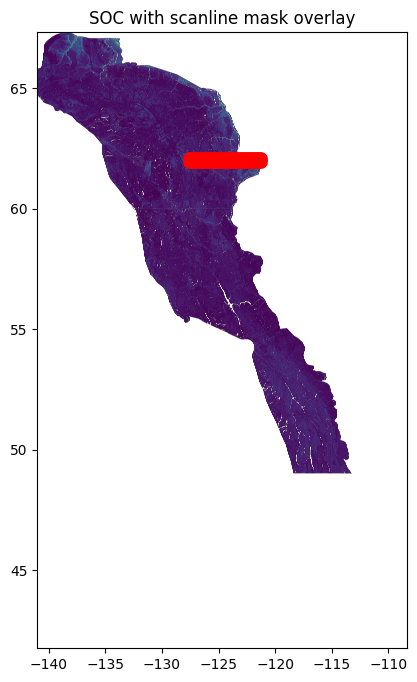

In [4]:
# check scanline mask overlay

fig, ax = plt.subplots(figsize=(8, 8))

# Plot raster
show(soc, transform=soc.rio.transform(), ax=ax, cmap="viridis")

# Plot vector on top
scanline_poly.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=10)

plt.title("SOC with scanline mask overlay")
plt.show()

In [5]:
# calculate the median of a 5x5 neighborhood
neighbor_median = soc.rolling(x=5, y=5, center=True).median(skipna=True)

diff = np.abs(soc - neighbor_median)

In [7]:
# Calculate the threshold for outlier pixels and mask outliers
mad = np.nanmedian(np.abs(diff - np.nanmedian(diff)))
threshold = 5 * mad
scan_mask = diff > threshold

In [8]:
# only keep outliers with at least 5 contiguous pixels
from scipy.ndimage import label

scan_mask_long = xr.zeros_like(scan_mask, dtype=bool)

for i in range(scan_mask.shape[0]):  # loop over rows
    row = scan_mask[i, :]
    labeled, n = label(row)
    for lab in range(1, n+1):
        idx = (labeled == lab)
        if idx.sum() >= 5:   # contiguous run length
            scan_mask_long[i, idx] = True

In [ ]:
# only keep outliers that fall within the scanline polygon
# first rasterize scanline polygon to a boolean "inside polygon" mask
scanline_mask = rasterize(
    ((geom, 1) for geom in scanline_poly.geometry if geom is not None and not geom.is_empty),
    out_shape=scan_mask_long.rio.shape,
    transform=scan_mask_long.rio.transform(),
    fill=0,
    all_touched=True,
    dtype='uint8'
).astype(bool)

# apply scanline mask to outlier mask
scan_mask_long = scan_mask_long & scanline_mask

In [10]:
# Define 3x3 footprint excluding center pixel
footprint = np.ones((3, 3), dtype=bool)
footprint[1, 1] = False

# Mask scanlines as NaN
soc_masked = soc.where(~scan_mask_long, np.nan)

# Median ignoring NaNs
neighbor_median = generic_filter(
    soc_masked,
    function=np.nanmedian,
    footprint=footprint,
    mode='constant',
    cval=np.nan
)

# Fill only scanline pixels
corrected = soc_masked.where(~scan_mask_long, neighbor_median)

/Users/ethanberman/Dropbox/Python Projects/y2y-carbon/.venv/lib/python3.14/site-packages/scipy/ndimage/_filters.py:2420: RuntimeWarning: All-NaN slice encountered
  _nd_image.generic_filter(input, function, footprint, output, mode,


In [ ]:
# export corrected raster and scanline mask to disk
corrected.rio.to_raster(
    "./carbon_stock_data/soc_correction/soc_scanline_corrected.tif",
    dtype="float32",
    nodata=np.nan,
)

scan_mask_long.rio.to_raster(
    "./carbon_stock_data/soc_correction/scanline_mask.tif",
    dtype="uint8"
)

## Fix SOC Artifact

In [ ]:
# set filepaths

# soc scanline corrected
soc_path = './carbon_stock_data/soc_correction/soc_scanline_corrected.tif'

# ecosystem classification
eco_path = './irrecoverable_data/ecosystems_classification_250m.tif'

# soc artifact path
artifact_path = './carbon_stock_data/soc_correction/soc_artifact.shp'
buffer_path = './carbon_stock_data/soc_correction/soc_artifact_ring_5km_buffer_20km.shp'

In [3]:
# set key parameters

# ecosystem classes to use
# Northern Forest (26), Northern Grasslands/Shrublands (29), Barren Lands (34)
eco_classes = [26,29,34] 

# --------------------
# Settings to start with
# --------------------
VARIOGRAM_MODEL = "exponential"   # try "spherical" first; then "exponential"
MIN_TRAIN_PTS   = 1000
MAX_TRAIN_PTS   = 25000         # subsample cap per class
CLIP_PCTS       = (1, 99)       # clip predictions to buffer distribution per class (helps prevent overshoot)

In [4]:
# load rasters
soc = rxr.open_rasterio(soc_path, masked=True).squeeze()
eco = rxr.open_rasterio(eco_path, masked=True).squeeze()

# get CRS
print("soc crs:", soc.rio.crs, "shape:", soc.shape, "res:", soc.rio.resolution())
print("eco crs:", eco.rio.crs,  "shape:", eco.shape,  "res:", eco.rio.resolution())

soc crs: EPSG:4326 shape: (11386, 14570) res: (0.0022457898480768247, -0.0022457903991559697)
eco crs: PROJCS["WGS_1984_Lambert_Azimuthal_Equal_Area",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",45],PARAMETER["longitude_of_center",-100],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]] shape: (12854, 4705) res: (250.00000000000003, -250.00000000000003)


In [5]:
# resample eco to match soc
eco_match = eco.rio.reproject_match(
    soc,
    resampling=Resampling.nearest
)

print("soc crs:", soc.rio.crs, "res:", soc.rio.resolution())
print("eco_match crs:", eco_match.rio.crs, "res:", eco_match.rio.resolution())

soc crs: EPSG:4326 res: (0.0022457898480768247, -0.0022457903991559697)
eco_match crs: EPSG:4326 res: (0.0022457898480768247, -0.0022457903991559697)


In [6]:
# load soc and eco parameters
soc_shape = soc.rio.shape
soc_trans = soc.rio.transform()
soc_crs = soc.rio.crs
soc_vals = soc.values.astype("float32")
eco_vals = eco_match.values

In [7]:
# load artifact and buffer
# reproject to match soc
artifact = gpd.read_file(artifact_path).to_crs(soc_crs)
buffer = gpd.read_file(buffer_path).to_crs(soc_crs)

# rasterize artifact and buffer masks
artifact_mask = rasterize(
    [(geom, 1) for geom in artifact.geometry if geom is not None and not geom.is_empty],
    out_shape=soc_shape,
    transform=soc_trans,
    fill=0,
    dtype="uint8",
    all_touched=True
).astype("uint8")

buffer_mask = rasterize(
    [(geom, 1) for geom in buffer.geometry if geom is not None and not geom.is_empty],
    out_shape=soc_shape,
    transform=soc_trans,
    fill=0,
    dtype="uint8",
    all_touched=True
).astype("uint8")

# set prediction base and training base
pred_base  = artifact_mask == 1
finite_soc = np.isfinite(soc_vals)
train_base = (buffer_mask == 1) & (artifact_mask == 0) & finite_soc

print("Artifact pixels:", int(pred_base.sum()))
print("Training pixels (buffer, valid):", int(train_base.sum()))

Artifact pixels: 75132
Training pixels (buffer, valid): 60470


In [8]:
# --------------------
# Helper: row/col -> x/y coords
# --------------------
def idx_to_xy(rows, cols, transform=soc_trans):
    x = transform.c + cols * transform.a + rows * transform.b
    y = transform.f + cols * transform.d + rows * transform.e
    return x.astype("float64"), y.astype("float64")

def ok_predict_points(x_t, y_t, z_t, x_p, y_p, variogram_model="spherical"):
    OK = OrdinaryKriging(
        x_t, y_t, z_t,
        variogram_model=variogram_model,
        verbose=False,
        enable_plotting=False,
        coordinates_type="euclidean",
    )
    z_pred, _ = OK.execute("points", x_p, y_p)
    return np.asarray(z_pred)

In [9]:
# --------------------
# Kriging fill (per landcover class)
# --------------------
filled_ok = soc_vals.copy()
filled_ok[pred_base] = np.nan

summary = []

for cls in eco_classes:
    train = train_base & (eco_vals == cls)
    pred  = pred_base  & (eco_vals == cls)

    n_train = int(train.sum())
    n_pred  = int(pred.sum())

    if n_pred == 0:
        summary.append((cls, n_train, n_pred, "skip (no pred)"))
        continue
    if n_train < MIN_TRAIN_PTS:
        summary.append((cls, n_train, n_pred, f"skip (train<{MIN_TRAIN_PTS})"))
        continue

    # training indices
    r_t, c_t = np.where(train)
    if n_train > MAX_TRAIN_PTS:
        sel = np.random.choice(n_train, size=MAX_TRAIN_PTS, replace=False)
        r_t, c_t = r_t[sel], c_t[sel]
        n_used = MAX_TRAIN_PTS
    else:
        n_used = n_train

    x_t, y_t = idx_to_xy(r_t, c_t)
    z_t = soc_vals[r_t, c_t].astype("float64")

    # prediction indices
    r_p, c_p = np.where(pred)
    x_p, y_p = idx_to_xy(r_p, c_p)

    print(f"[LC={cls}] OK train={n_train:,} (used {n_used:,}) pred={n_pred:,} variogram={VARIOGRAM_MODEL}")

    z_pred = ok_predict_points(x_t, y_t, z_t, x_p, y_p, variogram_model=VARIOGRAM_MODEL).astype("float32")

    # clip to plausible range from BUFFER training distribution (per class)
    lo, hi = np.nanpercentile(soc_vals[train], CLIP_PCTS[0]), np.nanpercentile(soc_vals[train], CLIP_PCTS[1])
    z_pred = np.clip(z_pred, lo, hi)

    filled_ok[r_p, c_p] = z_pred
    summary.append((cls, n_train, n_pred, "filled"))

summary

[LC=26] OK train=40,658 (used 25,000) pred=54,169 variogram=exponential
[LC=29] OK train=13,104 (used 13,104) pred=15,649 variogram=exponential
[LC=34] OK train=6,351 (used 6,351) pred=3,855 variogram=exponential


[(26, 40658, 54169, 'filled'),
 (29, 13104, 15649, 'filled'),
 (34, 6351, 3855, 'filled')]

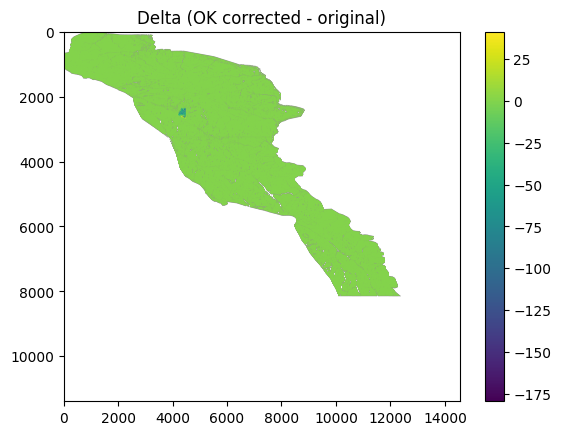

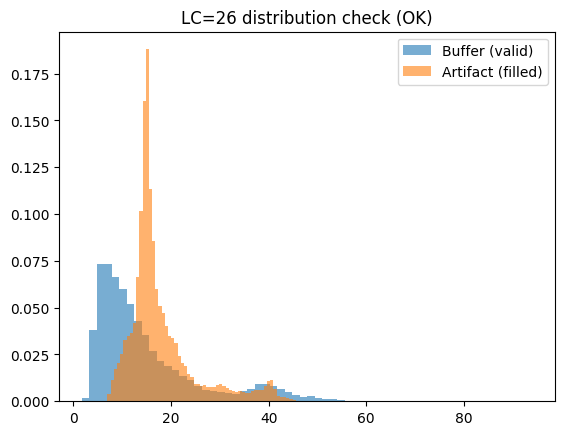

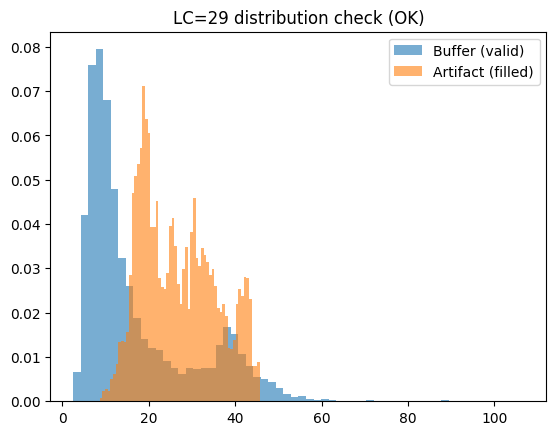

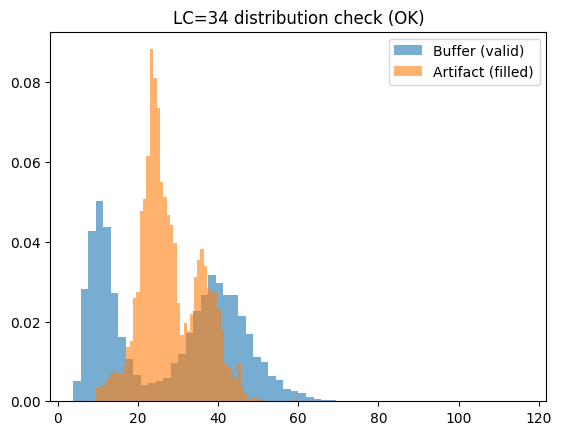

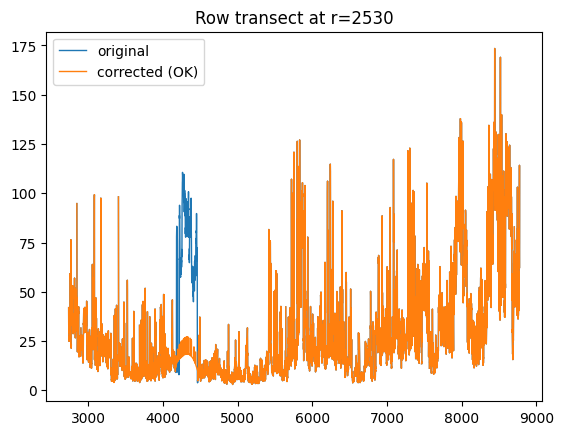

In [10]:
# ============================================================
# Quick diagnostics (same ones you used for IDW)
# ============================================================

delta = filled_ok - soc_vals

plt.figure()
plt.imshow(delta, aspect="auto")
plt.title("Delta (OK corrected - original)")
plt.colorbar()
plt.show()

# Distribution check per class: buffer vs filled inside artifact
for cls in eco_classes:
    buf = train_base & (eco_vals == cls)
    art = pred_base  & (eco_vals == cls)
    if buf.sum() == 0 or art.sum() == 0:
        continue

    plt.figure()
    plt.hist(soc_vals[buf][np.isfinite(soc_vals[buf])], bins=60, alpha=0.6, density=True, label="Buffer (valid)")
    plt.hist(filled_ok[art][np.isfinite(filled_ok[art])], bins=60, alpha=0.6, density=True, label="Artifact (filled)")
    plt.title(f"LC={cls} distribution check (OK)")
    plt.legend()
    plt.show()

# Simple transect through middle of artifact
rows, cols = np.where(pred_base)
if len(rows):
    r_mid = int(np.median(rows))
    plt.figure()
    plt.plot(soc_vals[r_mid, :], label="original", linewidth=1)
    plt.plot(filled_ok[r_mid, :], label="corrected (OK)", linewidth=1)
    plt.title(f"Row transect at r={r_mid}")
    plt.legend()
    plt.show()

In [36]:
import numpy as np
import geopandas as gpd
from rasterio.features import rasterize

RING_PATH = './carbon_stock_data/soc_correction/soc_artifact_buffer_neg2km_1km.shp'  # your 2km ring polygon

# Read ring polygon and match raster CRS
ring_gdf = gpd.read_file(RING_PATH).to_crs(soc.rio.crs)

# Rasterize ring to a band mask (True = pixels to blend)
ring_mask = rasterize(
    [(geom, 1) for geom in ring_gdf.geometry if geom is not None and not geom.is_empty],
    out_shape=soc_shape,
    transform=soc_trans,
    fill=0,
    dtype="uint8",
    all_touched=False
).astype(bool)

# Ensure we only blend *inside the artifact* (optional, but usually what you want)
band = ring_mask & pred_base

print("Band pixels:", int(band.sum()))

Band pixels: 7340


In [37]:
band_in  = ring_mask & pred_base      # 1 km INSIDE artifact
band_out = ring_mask & (~pred_base)   # 1 km OUTSIDE artifact

In [38]:
from scipy.ndimage import distance_transform_edt
from scipy.spatial import cKDTree
import numpy as np

def idx_to_xy(rows, cols, transform=soc_trans):
    # Affine: x = c + a*col + b*row ; y = f + d*col + e*row
    x = transform.c + cols * transform.a + rows * transform.b
    y = transform.f + cols * transform.d + rows * transform.e
    return x.astype("float64"), y.astype("float64")

def idw_knn(tree, z_known, xy_pred, k=48, power=2.0, eps=1e-12):
    dists, idx = tree.query(xy_pred, k=min(k, len(z_known)))
    if dists.ndim == 1:
        dists = dists[:, None]
        idx = idx[:, None]
    w = 1.0 / (np.maximum(dists, eps) ** power)
    z = z_known[idx]
    return (w * z).sum(axis=1) / w.sum(axis=1)

# Known pixels for IDW: valid SOC outside artifact (could include band_out; that's fine)
valid_outside = np.isfinite(soc_vals) & (~pred_base)
r_k, c_k = np.where(valid_outside)
x_k, y_k = idx_to_xy(r_k, c_k)
xy_known = np.column_stack([x_k, y_k])
z_known  = soc_vals[valid_outside].astype("float64")
tree = cKDTree(xy_known)

# Predict IDW for inside band pixels
r_in, c_in = np.where(band_in)
x_in, y_in = idx_to_xy(r_in, c_in)
xy_in = np.column_stack([x_in, y_in])

K, P = 64, 2.0
edge_idw_in = idw_knn(tree, z_known, xy_in, k=K, power=P).astype("float32")

# Weight ramp inside: 0 at boundary -> 1 at inner edge (1 km inside)
dist_in = distance_transform_edt(pred_base).astype("float32")  # distance to outside
d_in = dist_in[r_in, c_in]
dmax_in = np.max(d_in) if d_in.size else 1.0
w_in = np.clip(d_in / (dmax_in + 1e-6), 0, 1).astype("float32")

# Optional: make transition more kriging-dominant deeper inside
w_in = w_in**2

filled_both = filled_ok.copy()
filled_both[r_in, c_in] = (1 - w_in) * edge_idw_in + w_in * filled_ok[r_in, c_in]

In [39]:
# Known pixels for OUTSIDE IDW: valid SOC outside artifact AND outside the ring
valid_far = np.isfinite(soc_vals) & (~pred_base) & (~ring_mask)

r_k, c_k = np.where(valid_far)
x_k, y_k = idx_to_xy(r_k, c_k)
xy_known_far = np.column_stack([x_k, y_k])
z_known_far  = soc_vals[valid_far].astype("float64")
tree_far = cKDTree(xy_known_far)

# Predict IDW for outside band pixels
r_out, c_out = np.where(band_out)
x_out, y_out = idx_to_xy(r_out, c_out)
xy_out = np.column_stack([x_out, y_out])

edge_idw_out = idw_knn(tree_far, z_known_far, xy_out, k=K, power=P).astype("float32")

# Weight ramp outside: 0 at boundary -> 1 at OUTER edge (1 km outside)
# distance to nearest artifact pixel:
dist_out = distance_transform_edt(~pred_base).astype("float32")  # outside pixels -> distance to artifact
d_out = dist_out[r_out, c_out]
dmax_out = np.max(d_out) if d_out.size else 1.0
w_out = np.clip(d_out / (dmax_out + 1e-6), 0, 1).astype("float32")

# Optional curve (usually helps)
# w_out = w_out**2

# Blend: near boundary use smooth IDW; at outer edge return to ORIGINAL SOC
filled_both[r_out, c_out] = (1 - w_out) * edge_idw_out + w_out * soc_vals[r_out, c_out]

In [40]:
# import numpy as np
# from scipy.spatial import cKDTree
# from scipy.ndimage import distance_transform_edt

# # ring_mask: rasterized ring polygon (1 km outside + 1 km inside)
# # pred_base: artifact mask (True inside artifact)
# band_in  = ring_mask & pred_base
# # band_out = ring_mask & (~pred_base)  # optional if you ever want it

# # --- IDW reference surface computed for band_in pixels only ---
# valid_outside = np.isfinite(soc_vals) & (~pred_base)

# r_k, c_k = np.where(valid_outside)
# x_k, y_k = idx_to_xy(r_k, c_k)
# xy_known = np.column_stack([x_k, y_k])
# z_known  = soc_vals[valid_outside].astype("float64")

# tree = cKDTree(xy_known)

# r_b, c_b = np.where(band_in)                 # <-- changed from band to band_in
# x_b, y_b = idx_to_xy(r_b, c_b)
# xy_band  = np.column_stack([x_b, y_b])

# K = 48
# P = 2.0
# edge_idw_in = idw_knn(tree, z_known, xy_band, k=K, power=P).astype("float32")

# # --- Weight ramp: 0 at boundary -> 1 at inner edge of band_in ---
# # dist_pix gives distance from each artifact pixel to the boundary (in pixels)
# dist_pix = distance_transform_edt(pred_base).astype("float32")

# # Only look at distances within band_in
# d = dist_pix[r_b, c_b]
# dmax = np.max(d) if d.size else 1.0

# # Weight in [0,1], guaranteed to reach 1 at the inner edge of band_in
# w = np.clip(d / (dmax + 1e-6), 0, 1).astype("float32")

# # --- Blend ONLY inside band_in ---
# filled_blend = filled_ok.copy()
# krig_vals = filled_ok[r_b, c_b].astype("float32")

# filled_blend[r_b, c_b] = (1 - w) * edge_idw_in + w * krig_vals

In [41]:
# from scipy.ndimage import distance_transform_edt

# # Distance (in pixels) from artifact pixels to nearest non-artifact pixel
# # This is used only to create a smooth ramp; the band itself defines the 2km extent.
# dist_pix = distance_transform_edt(pred_base)

# # Normalize distance within the band to [0,1]
# d_band = dist_pix[r_b, c_b].astype("float32")
# d_max = np.max(d_band) if len(d_band) else 1.0
# w_band = np.clip(d_band / (d_max + 1e-6), 0, 1).astype("float32")

# filled_blend = filled_ok.copy()
# krig_band = filled_ok[r_b, c_b].astype("float32")

# filled_blend[r_b, c_b] = (1 - w_band) * edge_idw + w_band * krig_band

In [42]:
# ============================================================
# 7) Export corrected raster + mask
# ============================================================

# set output paths
soc_out_path = './carbon_stock_data/soc_correction/soc_scanline_artifact_corrected_5kring_20kbuf_25kpts_exp_edge_neg2km_1km_5.tif'
soc_mask_out_path = './carbon_stock_data/soc_correction/soc_artifact_mask_5kring_20kbuf_25kpts_exp_edge_neg2km_1km_5.tif'

filled_da = xr.DataArray(filled_both, coords=soc.coords, dims=soc.dims, attrs=soc.attrs).rio.write_crs(soc.rio.crs)
mask_da   = xr.DataArray(artifact_mask, coords=soc.coords, dims=soc.dims).rio.write_crs(soc.rio.crs)

# set nodata explicitly to NaN
filled_da = filled_da.rio.write_nodata(soc.rio.nodata) 
mask_da   = mask_da.rio.write_nodata(0)

filled_da.rio.to_raster(soc_out_path, compress="DEFLATE")
mask_da.rio.to_raster(soc_mask_out_path, compress="DEFLATE")